# Seleção Científica de Método de Binarização

## Objetivo

Este notebook realiza uma **comparação científica e objetiva** de 4 métodos de binarização para selecionar o método de produção ideal.

### Métodos Avaliados

1. **`blur_morphology`** - Blur Gaussiano + Morphological Opening
2. **`limiar_simples`** - Threshold Simples (baseline)
3. **`blur_gaussiano`** - Gaussian Blur apenas
4. **`filtro_bilateral`** - Bilateral Filter (preservação de bordas)

### Critérios de Avaliação (Pesos)

1. **Consistência** (40%) - Menor variação entre imagens (CV)
2. **Circularidade** (30%) - Forma mais próxima do círculo ideal
3. **Suavidade** (30%) - Bordas menos serrilhadas

**Nota:** Fragmentos e buracos são coletados para análise mas não pontuados (representam anatomia natural do búfalo).

### Dataset

- **387 imagens JPG** de búfalos
- **4 conjuntos de máscaras PNG** geradas (1 por método)
- Máscaras binárias: búfalo (branco), fundo (preto)

## 1. Setup e Importações

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Adicionar src ao path
sys.path.append(str(Path.cwd().parent / 'src'))

from config import GENERATED_DIR, DATA_DIR

# Configuração de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Setup completo")
print(f"📁 GENERATED_DIR: {GENERATED_DIR}")
print(f"📁 DATA_DIR: {DATA_DIR}")

✅ Setup completo
📁 GENERATED_DIR: /home/victor/Projects/projeto-bufalos/generated
📁 DATA_DIR: /home/victor/Projects/projeto-bufalos/data


## 2. Funções Auxiliares de Métricas

Funções para calcular métricas de qualidade das máscaras binárias.

**Nota:** Estas funções são **somente para análise** e replicam a lógica da classe `Mascara` de produção (área e perímetro Euclidiano validados no Notebook 03).

In [2]:
def calcular_circularidade(area: float, perimetro: float) -> float:
    """
    Circularidade = 4π × Area / Perímetro²
    Valor ideal = 1.0 (círculo perfeito)
    Valores < 1.0 indicam formas alongadas ou irregulares
    """
    if perimetro == 0:
        return 0.0
    return (4 * np.pi * area) / (perimetro ** 2)


def calcular_area(mascara_array: np.ndarray) -> int:
    """
    Calcula área da máscara (número de pixels brancos).
    """
    return int((mascara_array == 255).sum())


def calcular_perimetro(mascara_array: np.ndarray) -> float:
    """
    Calcula perímetro usando distância Euclidiana (cv2.arcLength).
    
    Método CORRETO validado no Notebook 03:
    - Euclidiano simula medição com fita métrica
    - Manhattan superestima em ~20% (erro amplifica para 44% no peso)
    """
    binary_mask = (mascara_array > 0).astype(np.uint8)
    
    # Encontra contornos externos
    contours, _ = cv2.findContours(
        binary_mask,
        cv2.RETR_EXTERNAL,  # Apenas contorno externo
        cv2.CHAIN_APPROX_NONE,  # Todos os pontos (sem aproximação)
    )
    
    if len(contours) == 0:
        return 0.0
    
    # Soma perímetros de todos os contornos
    perimetro_total = sum(cv2.arcLength(cnt, closed=True) for cnt in contours)
    
    return float(perimetro_total)


def calcular_suavidade_borda(mascara_array: np.ndarray) -> float:
    """
    Suavidade de borda = desvio padrão da curvatura
    Menor valor = borda mais suave (menos serrilhada)
    """
    contours, _ = cv2.findContours(mascara_array, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(contours) == 0:
        return 0.0
    
    # Usar o maior contorno (búfalo principal)
    contour = max(contours, key=cv2.contourArea)
    
    if len(contour) < 5:
        return 0.0
    
    # Calcular curvatura usando diferenças de ângulo
    contour = contour.reshape(-1, 2)
    
    # Vetores de direção
    dx = np.diff(contour[:, 0])
    dy = np.diff(contour[:, 1])
    
    # Ângulos
    angles = np.arctan2(dy, dx)
    
    # Diferença de ângulos (curvatura)
    curvature = np.diff(angles)
    
    # Normalizar para [-π, π]
    curvature = np.arctan2(np.sin(curvature), np.cos(curvature))
    
    return np.std(curvature)


def calcular_razao_perimetro_area(area: float, perimetro: float) -> float:
    """
    Razão Perímetro/Área = P / √A
    Normalizado para ser independente de escala
    Menor valor = forma mais compacta
    """
    if area == 0:
        return 0.0
    return perimetro / np.sqrt(area)


def contar_fragmentos(mascara_array: np.ndarray) -> int:
    """
    Conta número de componentes conectados (fragmentação)
    Ideal = 1 (apenas o búfalo, sem ruído)
    """
    num_labels, _ = cv2.connectedComponents(mascara_array)
    return num_labels - 1  # Subtrair background


def contar_buracos(mascara_array: np.ndarray) -> int:
    """
    Conta número de buracos internos (contornos internos)
    Ideal = 0 (máscara sólida)
    """
    contours, hierarchy = cv2.findContours(mascara_array, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    
    if hierarchy is None:
        return 0
    
    # Contar contornos com parent (contornos internos = buracos)
    holes = np.sum(hierarchy[0][:, 3] >= 0)
    return holes


def extrair_metricas(mascara_path: Path, metodo: str, imagem_nome: str) -> dict:
    """
    Extrai todas as métricas de uma máscara
    """
    # Carregar máscara como array
    mascara_array = cv2.imread(str(mascara_path), cv2.IMREAD_GRAYSCALE)
    
    # Métricas primárias
    area = calcular_area(mascara_array)
    perimetro = calcular_perimetro(mascara_array)
    
    # Métricas derivadas
    circularidade = calcular_circularidade(area, perimetro)
    suavidade = calcular_suavidade_borda(mascara_array)
    razao_pa = calcular_razao_perimetro_area(area, perimetro)
    fragmentos = contar_fragmentos(mascara_array)
    buracos = contar_buracos(mascara_array)
    
    return {
        'imagem': imagem_nome,
        'metodo': metodo,
        'area': area,
        'perimetro': perimetro,
        'circularidade': circularidade,
        'suavidade_borda': suavidade,
        'razao_perimetro_area': razao_pa,
        'fragmentos': fragmentos,
        'buracos': buracos
    }


print("✅ Funções auxiliares definidas")

✅ Funções auxiliares definidas


## 3. Configuração de Caminhos

In [3]:
# Diretórios dos 4 métodos
METODOS = {
    'blur_morphology': Path(GENERATED_DIR) / 'Ground-of-truth' / 'blur_morphology',
    'limiar_simples': Path(GENERATED_DIR) / 'Ground-of-truth' / 'limiar_simples',
    'blur_gaussiano': Path(GENERATED_DIR) / 'Ground-of-truth' / 'blur_gaussiano',
    'filtro_bilateral': Path(GENERATED_DIR) / 'Ground-of-truth' / 'filtro_bilateral'
}

# Verificar existência
for metodo, path in METODOS.items():
    if path.exists():
        num_files = len(list(path.glob('*.png')))
        print(f"✅ {metodo}: {num_files} arquivos")
    else:
        print(f"❌ {metodo}: diretório não encontrado - {path}")

✅ blur_morphology: 387 arquivos
✅ limiar_simples: 387 arquivos
✅ blur_gaussiano: 387 arquivos
✅ filtro_bilateral: 387 arquivos


## 4. Coleta de Métricas (4 métodos × 387 imagens)

Este processo pode levar alguns minutos...

In [4]:
# Coletar métricas de todos os métodos
resultados = []

for metodo, dir_path in METODOS.items():
    print(f"\n🔄 Processando método: {metodo}")
    
    mascaras = sorted(dir_path.glob('*.png'))
    
    for i, mascara_path in enumerate(mascaras):
        try:
            metricas = extrair_metricas(mascara_path, metodo, mascara_path.name)
            resultados.append(metricas)
            
            if (i + 1) % 100 == 0:
                print(f"  ✓ {i+1}/{len(mascaras)} processadas")
                
        except Exception as e:
            print(f"  ⚠️  Erro em {mascara_path.name}: {e}")
    
    print(f"✅ {metodo}: {len(mascaras)} máscaras processadas")

# Criar DataFrame
df = pd.DataFrame(resultados)

print(f"\n📊 Total de registros: {len(df)}")
print(f"📊 Métodos: {df['metodo'].nunique()}")
print(f"📊 Imagens únicas: {df['imagem'].nunique()}")

df.head(10)


🔄 Processando método: blur_morphology
  ✓ 100/387 processadas
  ✓ 200/387 processadas
  ✓ 300/387 processadas
✅ blur_morphology: 387 máscaras processadas

🔄 Processando método: limiar_simples
  ✓ 100/387 processadas
  ✓ 200/387 processadas
  ✓ 300/387 processadas
✅ limiar_simples: 387 máscaras processadas

🔄 Processando método: blur_gaussiano
  ✓ 100/387 processadas
  ✓ 200/387 processadas
  ✓ 300/387 processadas
✅ blur_gaussiano: 387 máscaras processadas

🔄 Processando método: filtro_bilateral
  ✓ 100/387 processadas
  ✓ 200/387 processadas
  ✓ 300/387 processadas
✅ filtro_bilateral: 387 máscaras processadas

📊 Total de registros: 1548
📊 Métodos: 4
📊 Imagens únicas: 387


,imagem,metodo,area,perimetro,circularidade,suavidade_borda,razao_perimetro_area,fragmentos,buracos
0,0266d87e-faec-497f-8e14-949a5ab6afa3.png,blur_morphology,413731,6242.356885,0.133423,0.504212,9.704866,1,0
1,034d9e54-2983-466e-9a2b-19cb0f638536.png,blur_morphology,520476,7139.709259,0.128307,0.534528,9.896467,1,0
2,05a68a22-1729-42ea-8883-e6b90dd8a789.png,blur_morphology,2443293,9753.136000,0.322773,0.529533,6.239596,1,0
3,069d2cff-0b33-42bc-b85e-a4b740860bc1.png,blur_morphology,1558419,10086.498479,0.192492,0.511298,8.079757,1,0
4,0831a96e-316e-4041-9025-4d30c31eb021.png,blur_morphology,211776,3818.303939,0.182535,0.522088,8.297211,1,0
5,0bfd53d9-1efc-44a4-b8e7-09bb28b556ef.png,blur_morphology,1644961,11001.334046,0.170795,0.510056,8.577635,1,0
6,1015_Calcula_515.png,blur_morphology,189772,3560.036913,0.188162,0.520942,8.172190,1,0
7,101_Calcula_576.png,blur_morphology,64536,1898.219467,0.225071,0.496349,7.472147,1,1
8,1028_Calcula_483.png,blur_morphology,181002,3463.735397,0.189585,0.529758,8.141474,1,0
9,1042_Calcula_494.png,blur_morphology,540508,6095.182348,0.182826,0.513954,8.290594,1,1


## 5. Estatísticas Descritivas por Método

In [5]:
# Estatísticas por método
metricas_numericas = ['area', 'perimetro', 'circularidade', 'suavidade_borda', 
                      'razao_perimetro_area', 'fragmentos', 'buracos']

estatisticas = df.groupby('metodo')[metricas_numericas].agg([
    'mean', 'std', 'min', 'max', 'median'
]).round(4)

print("📊 Estatísticas Descritivas por Método\n")
print(estatisticas)

# Salvar para referência
estatisticas.to_csv(Path(GENERATED_DIR) / 'comparacao_binarizacao_resumo.csv')
print(f"\n💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_binarizacao_resumo.csv'}")

📊 Estatísticas Descritivas por Método

                          area                                          \
                          mean           std    min      max    median   
metodo                                                                   
blur_gaussiano    1.201666e+06  1.080866e+06  30546  5136370  862572.0   
blur_morphology   1.201659e+06  1.080866e+06  30544  5136356  862565.0   
filtro_bilateral  1.201880e+06  1.080975e+06  30584  5136836  862807.0   
limiar_simples    1.201863e+06  1.080966e+06  30581  5136806  862793.0   

                  perimetro                                               ...  \
                       mean        std        min         max     median  ...   
metodo                                                                    ...   
blur_gaussiano    7711.7039  4214.5827  1211.7859  19286.5021  7522.6180  ...   
blur_morphology   7707.5275  4214.0662  1207.6438  19273.1884  7512.5764  ...   
filtro_bilateral  7727.4387  4218.047

## 6. Visualização 1: Comparação Side-by-Side (Piores Casos)

Visualizar os 4 métodos aplicados às piores imagens segundo cada métrica:
- Linha 1: Pior circularidade (mais distante de 1.0)
- Linha 2: Pior suavidade de borda (maior desvio padrão)
- Linha 3: Maior número de fragmentos

📊 Piores casos identificados:

  • Pior Circularidade: 034d9e54-2983-466e-9a2b-19cb0f638536.png
    - Circularidade: 0.1283
    - Suavidade: 0.5345
    - Fragmentos: 1

  • Pior Suavidade: 98_Calcula_484.png
    - Circularidade: 0.1487
    - Suavidade: 0.5682
    - Fragmentos: 1

  • Maior Fragmentação: 1137_Calcula_519.png
    - Circularidade: 0.1434
    - Suavidade: 0.5289
    - Fragmentos: 3



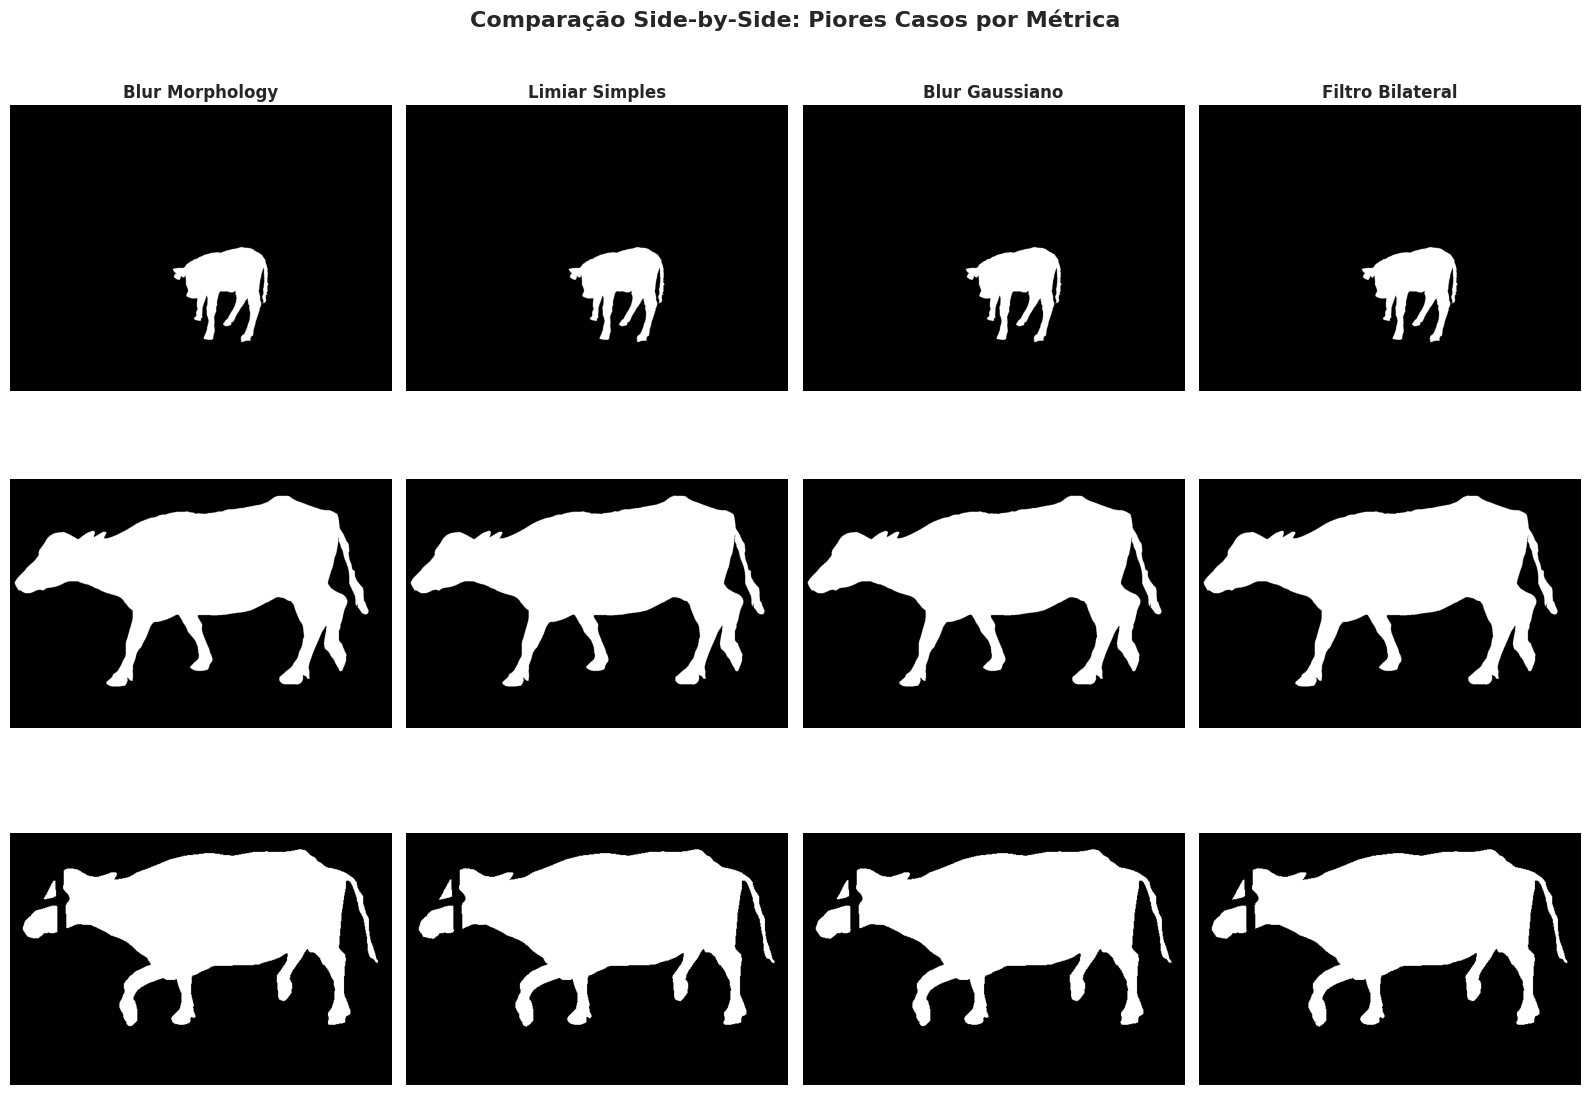

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_sidebyside.png


In [6]:
# Identificar piores imagens por métrica (usando método blur_morphology como referência)
df_blur_morph = df[df['metodo'] == 'blur_morphology'].copy()

# 1. Pior circularidade (mais distante de 1.0 = menor valor)
pior_circ = df_blur_morph.nsmallest(1, 'circularidade')['imagem'].iloc[0]

# 2. Pior suavidade (maior desvio padrão = mais serrilhada)
pior_suav = df_blur_morph.nlargest(1, 'suavidade_borda')['imagem'].iloc[0]

# 3. Maior fragmentação (mais componentes desconexos)
pior_frag = df_blur_morph.nlargest(1, 'fragmentos')['imagem'].iloc[0]

# Lista de piores casos
piores_casos = [
    (pior_circ, 'Pior Circularidade'),
    (pior_suav, 'Pior Suavidade'),
    (pior_frag, 'Maior Fragmentação')
]

print("📊 Piores casos identificados:\n")
for img_name, descricao in piores_casos:
    metricas = df_blur_morph[df_blur_morph['imagem'] == img_name].iloc[0]
    print(f"  • {descricao}: {img_name}")
    print(f"    - Circularidade: {metricas['circularidade']:.4f}")
    print(f"    - Suavidade: {metricas['suavidade_borda']:.4f}")
    print(f"    - Fragmentos: {metricas['fragmentos']:.0f}\n")

# Criar visualização
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.suptitle('Comparação Side-by-Side: Piores Casos por Métrica', fontsize=16, fontweight='bold')

for row_idx, (img_name, descricao) in enumerate(piores_casos):
    for col_idx, (metodo, dir_path) in enumerate(METODOS.items()):
        # Carregar imagem
        img_path = dir_path / img_name
        img = Image.open(img_path)
        
        # Plotar
        ax = axes[row_idx, col_idx]
        ax.imshow(img, cmap='gray')
        ax.axis('off')
        
        # Título apenas na primeira linha
        if row_idx == 0:
            ax.set_title(metodo.replace('_', ' ').title(), fontweight='bold')
        
        # Descrição do caso na primeira coluna
        if col_idx == 0:
            ax.set_ylabel(descricao, rotation=0, ha='right', va='center', 
                         fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig(Path(GENERATED_DIR) / 'comparacao_sidebyside.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_sidebyside.png'}")

## 7. Visualização 2: Histogramas de Distribuição

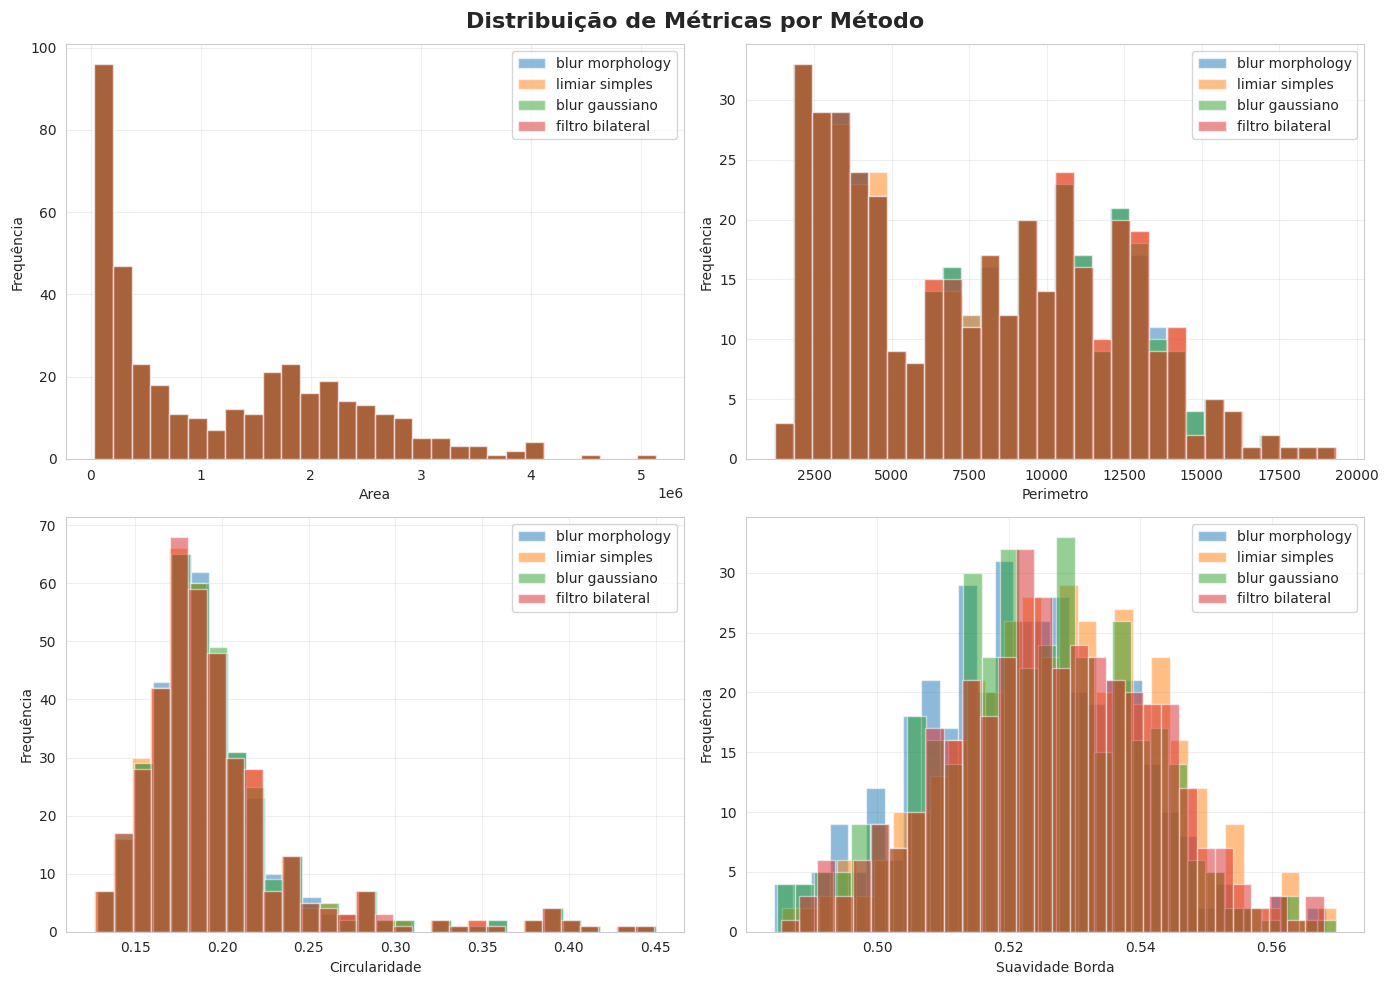

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_histogramas.png


In [7]:
# Métricas principais para histograma
metricas_plot = ['area', 'perimetro', 'circularidade', 'suavidade_borda']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribuição de Métricas por Método', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, metrica in enumerate(metricas_plot):
    ax = axes[idx]
    
    for metodo in METODOS.keys():
        dados = df[df['metodo'] == metodo][metrica]
        ax.hist(dados, bins=30, alpha=0.5, label=metodo.replace('_', ' '))
    
    ax.set_xlabel(metrica.replace('_', ' ').title())
    ax.set_ylabel('Frequência')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(GENERATED_DIR) / 'comparacao_histogramas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_histogramas.png'}")

## 8. Visualização 3: Box Plots Comparativos

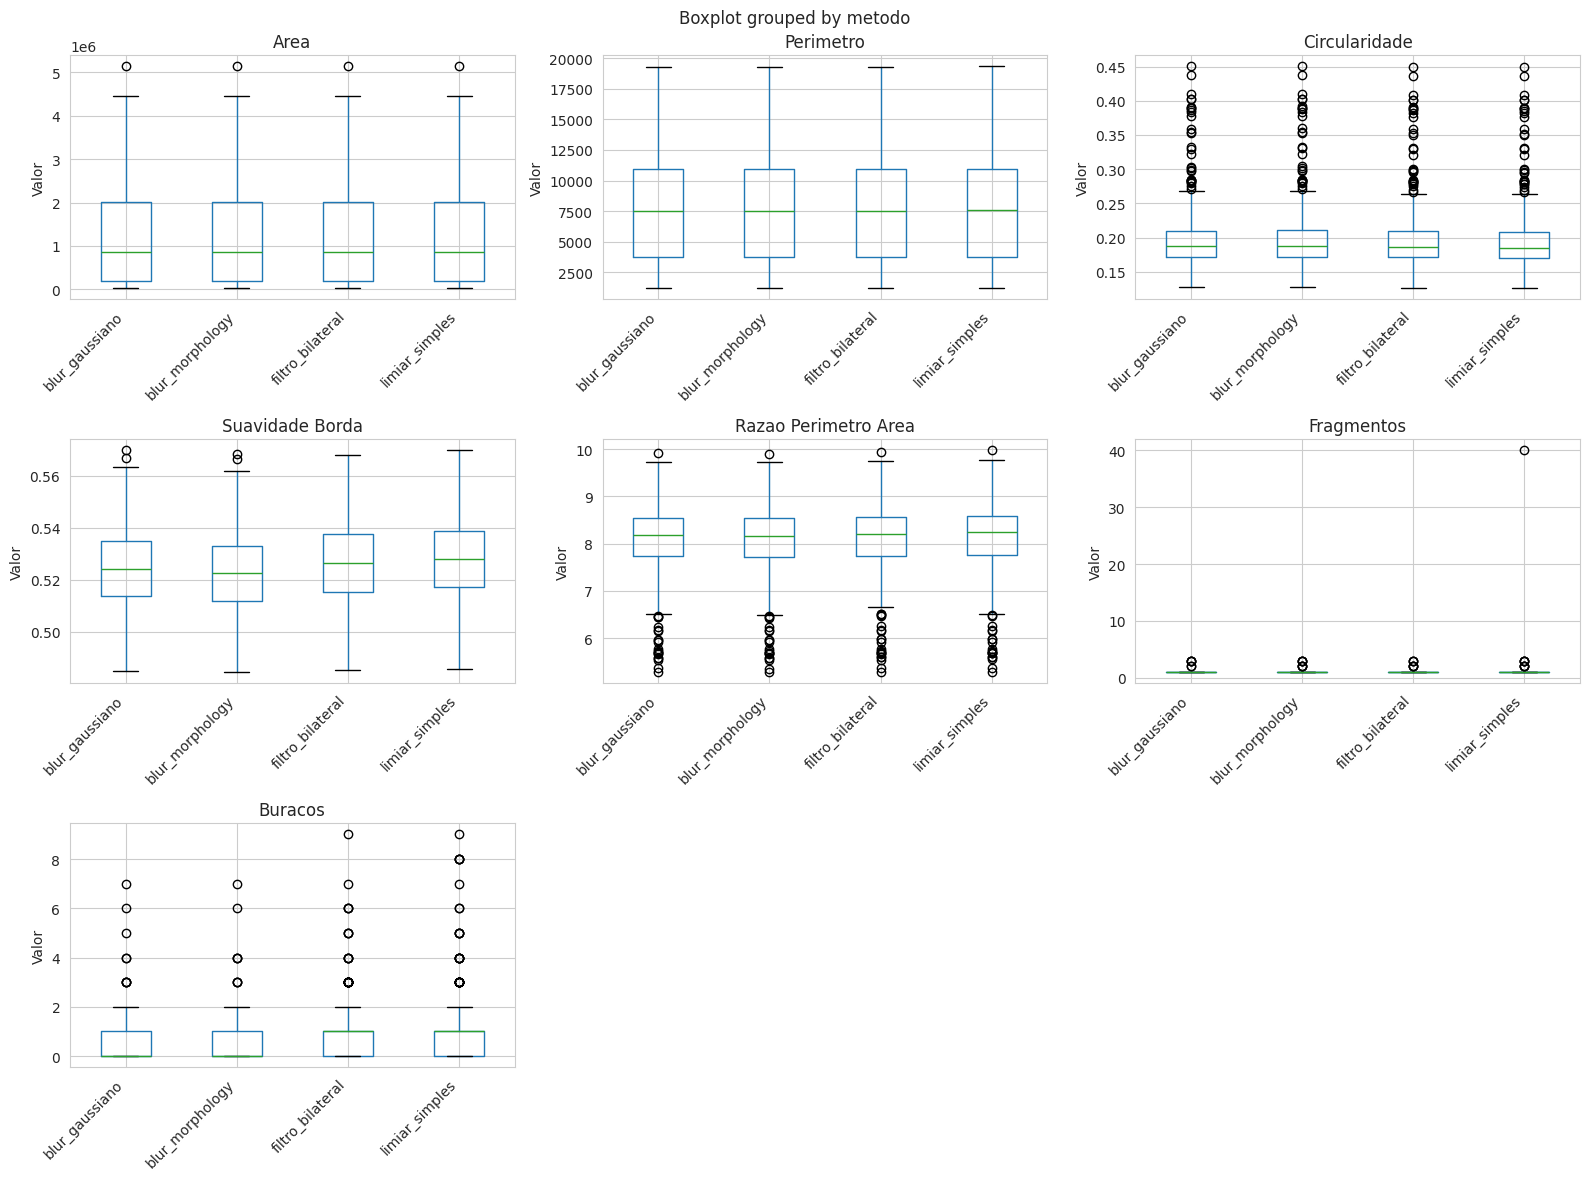

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_boxplots.png


In [8]:
# Box plots para todas as 7 métricas
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Box Plots: Comparação de Métricas entre Métodos', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, metrica in enumerate(metricas_numericas):
    ax = axes[idx]
    
    df.boxplot(column=metrica, by='metodo', ax=ax)
    ax.set_title(metrica.replace('_', ' ').title())
    ax.set_xlabel('')
    ax.set_ylabel('Valor')
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')

# Remover subplots extras
for idx in range(len(metricas_numericas), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig(Path(GENERATED_DIR) / 'comparacao_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_boxplots.png'}")

## 9. Visualização 4: Scatter Plots (Correlações)

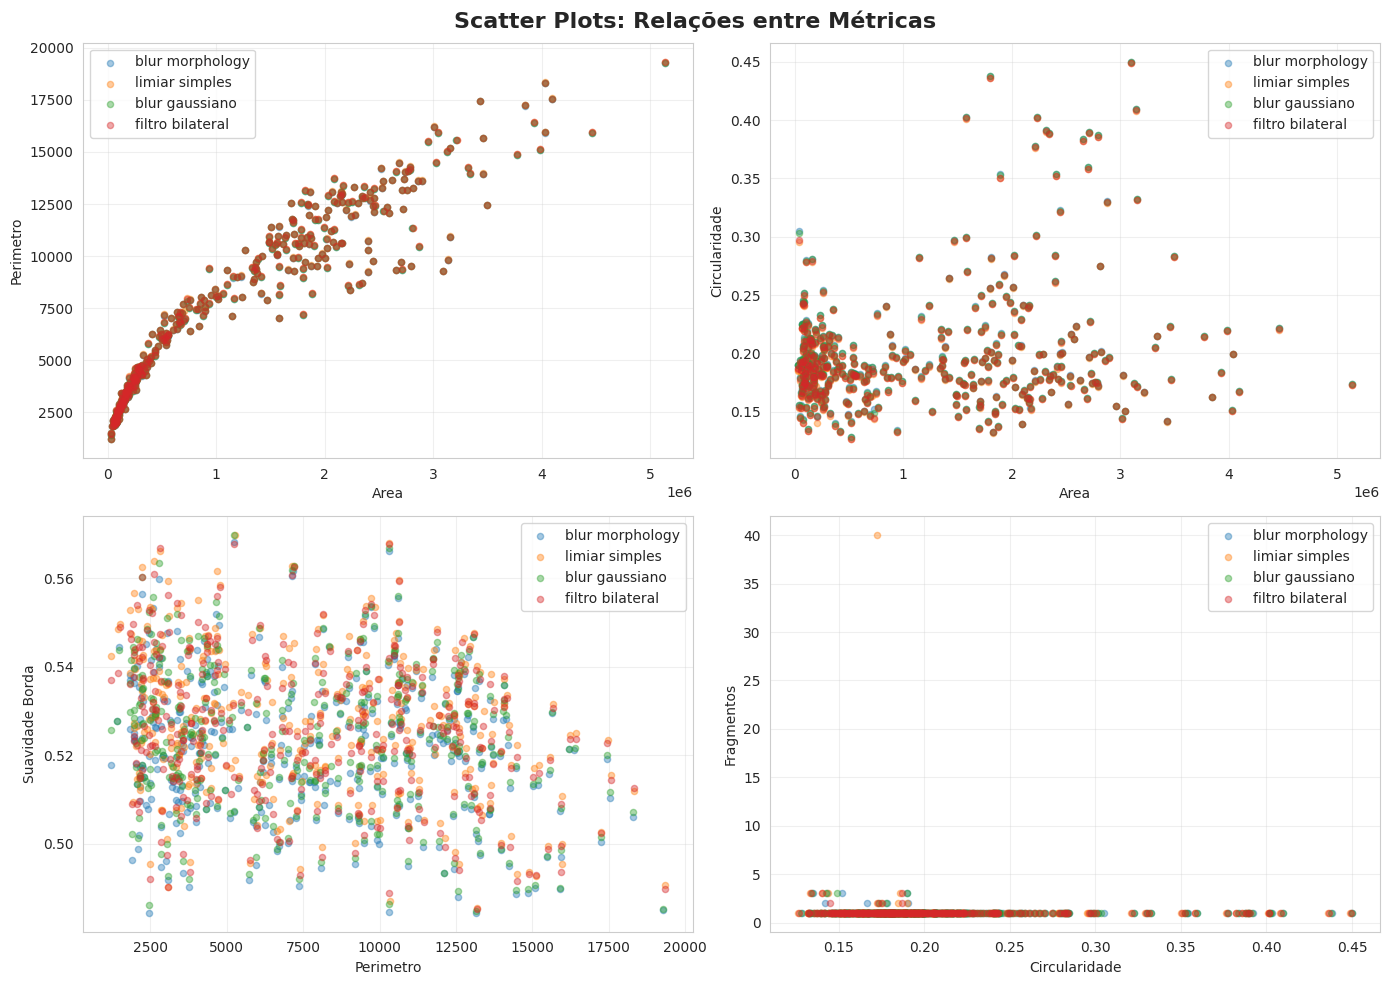

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_scatterplots.png


In [9]:
# Scatter plots de relações importantes
scatter_pairs = [
    ('area', 'perimetro'),
    ('area', 'circularidade'),
    ('perimetro', 'suavidade_borda'),
    ('circularidade', 'fragmentos')
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scatter Plots: Relações entre Métricas', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, (x_var, y_var) in enumerate(scatter_pairs):
    ax = axes[idx]
    
    for metodo in METODOS.keys():
        dados = df[df['metodo'] == metodo]
        ax.scatter(dados[x_var], dados[y_var], alpha=0.4, label=metodo.replace('_', ' '), s=20)
    
    ax.set_xlabel(x_var.replace('_', ' ').title())
    ax.set_ylabel(y_var.replace('_', ' ').title())
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(Path(GENERATED_DIR) / 'comparacao_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_scatterplots.png'}")

## 10. Visualização 5: Heatmaps de Correlação (1 por método)

In [10]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path
from PIL import Image
import warnings

warnings.filterwarnings('ignore')

# Adicionar src ao path
sys.path.append(str(Path.cwd().parent / 'src'))

from config import GENERATED_DIR, DATA_DIR

# Configuração de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ Setup completo")
print(f"📁 GENERATED_DIR: {GENERATED_DIR}")
print(f"📁 DATA_DIR: {DATA_DIR}")

✅ Setup completo
📁 GENERATED_DIR: /home/victor/Projects/projeto-bufalos/generated
📁 DATA_DIR: /home/victor/Projects/projeto-bufalos/data


## 11. Análise de Consistência (Coeficiente de Variação)

In [11]:
# Calcular CV (Coefficient of Variation) = std / mean
cv_data = []

for metodo in METODOS.keys():
    dados_metodo = df[df['metodo'] == metodo]
    
    for metrica in metricas_numericas:
        mean_val = dados_metodo[metrica].mean()
        std_val = dados_metodo[metrica].std()
        cv = (std_val / mean_val * 100) if mean_val != 0 else 0
        
        cv_data.append({
            'metodo': metodo,
            'metrica': metrica,
            'cv_percent': cv
        })

df_cv = pd.DataFrame(cv_data)

# Pivot para visualização
cv_pivot = df_cv.pivot(index='metrica', columns='metodo', values='cv_percent').round(2)

print("📊 Coeficiente de Variação (%) - Menor = Mais Consistente\n")
print(cv_pivot)

# CV médio por método (métrica agregada de consistência)
cv_medio = df_cv.groupby('metodo')['cv_percent'].mean().sort_values()
print("\n🏆 Ranking de Consistência (CV médio - menor é melhor):\n")
print(cv_medio)

📊 Coeficiente de Variação (%) - Menor = Mais Consistente

metodo                blur_gaussiano  blur_morphology  filtro_bilateral  \
metrica                                                                   
area                           89.95            89.95             89.94   
buracos                       154.28           152.45            140.07   
circularidade                  25.39            25.35             25.48   
fragmentos                     20.90            21.87             19.69   
perimetro                      54.65            54.67             54.59   
razao_perimetro_area            9.99             9.98             10.01   
suavidade_borda                 3.00             2.99              3.00   

metodo                limiar_simples  
metrica                               
area                           89.94  
buracos                       152.21  
circularidade                  25.60  
fragmentos                    176.16  
perimetro                      5

## 12. Análise de Qualidade (Circularidade, Fragmentação, Buracos)

In [12]:
# Métricas de qualidade
qualidade = df.groupby('metodo').agg({
    'circularidade': 'mean',  # Maior = melhor (próximo de 1)
    'fragmentos': 'mean',      # Menor = melhor (ideal = 1)
    'buracos': 'mean'          # Menor = melhor (ideal = 0)
}).round(4)

print("📊 Análise de Qualidade\n")
print(qualidade)

# Ranking individual
print("\n🏆 Ranking de Circularidade (maior = melhor):")
print(qualidade['circularidade'].sort_values(ascending=False))

print("\n🏆 Ranking de Fragmentação (menor = melhor):")
print(qualidade['fragmentos'].sort_values())

print("\n🏆 Ranking de Buracos (menor = melhor):")
print(qualidade['buracos'].sort_values())

📊 Análise de Qualidade

                  circularidade  fragmentos  buracos
metodo                                              
blur_gaussiano           0.1992      1.0258   0.5556
blur_morphology          0.1995      1.0310   0.5504
filtro_bilateral         0.1983      1.0258   0.8450
limiar_simples           0.1976      1.1318   0.9044

🏆 Ranking de Circularidade (maior = melhor):
metodo
blur_morphology     0.1995
blur_gaussiano      0.1992
filtro_bilateral    0.1983
limiar_simples      0.1976
Name: circularidade, dtype: float64

🏆 Ranking de Fragmentação (menor = melhor):
metodo
blur_gaussiano      1.0258
filtro_bilateral    1.0258
blur_morphology     1.0310
limiar_simples      1.1318
Name: fragmentos, dtype: float64

🏆 Ranking de Buracos (menor = melhor):
metodo
blur_morphology     0.5504
blur_gaussiano      0.5556
filtro_bilateral    0.8450
limiar_simples      0.9044
Name: buracos, dtype: float64


## 13. Sistema de Pontuação Final

### Pesos dos Critérios (CORRIGIDO):
- **Consistência** (CV médio): 40%
- **Circularidade**: 30%
- **Suavidade** (borda): 30%

### ❌ Removidos da pontuação:
- **Fragmentação**: Partes desconexas são anatomia natural (chifres, orelhas, rabo)
- **Buracos**: Espaços internos são anatomia natural (entre pernas, características corporais)

### Normalização:
- Métricas "menor é melhor" são invertidas
- Todas as pontuações normalizadas para 0-100

In [13]:
# Calcular scores por critério
scores = []

for metodo in METODOS.keys():
    dados_metodo = df[df['metodo'] == metodo]
    
    # 1. Consistência (CV médio - menor é melhor)
    cv_metodo = df_cv[df_cv['metodo'] == metodo]['cv_percent'].mean()
    
    # 2. Circularidade média (maior é melhor)
    circ_media = dados_metodo['circularidade'].mean()
    
    # 3. Suavidade média (menor é melhor)
    suavidade_media = dados_metodo['suavidade_borda'].mean()
    
    # 4. Fragmentação média (menor é melhor)
    frag_media = dados_metodo['fragmentos'].mean()
    
    # 5. Buracos médios (menor é melhor)
    buracos_media = dados_metodo['buracos'].mean()
    
    scores.append({
        'metodo': metodo,
        'cv_medio': cv_metodo,
        'circularidade': circ_media,
        'suavidade': suavidade_media,
        'fragmentacao': frag_media,
        'buracos': buracos_media
    })

df_scores = pd.DataFrame(scores)

# Normalização Min-Max para 0-100
def normalizar_min_max(serie, inverter=False):
    """Normaliza para 0-100. Se inverter=True, menor valor recebe 100."""
    min_val = serie.min()
    max_val = serie.max()
    
    if max_val == min_val:
        return pd.Series([50] * len(serie), index=serie.index)
    
    norm = (serie - min_val) / (max_val - min_val) * 100
    
    if inverter:
        norm = 100 - norm
    
    return norm

# Aplicar normalização
df_scores['score_consistencia'] = normalizar_min_max(df_scores['cv_medio'], inverter=True)
df_scores['score_circularidade'] = normalizar_min_max(df_scores['circularidade'], inverter=False)
df_scores['score_suavidade'] = normalizar_min_max(df_scores['suavidade'], inverter=True)
# df_scores['score_fragmentacao'] = normalizar_min_max(df_scores['fragmentacao'], inverter=True)  # REMOVIDO
# df_scores['score_buracos'] = normalizar_min_max(df_scores['buracos'], inverter=True)  # REMOVIDO

# Pesos CORRIGIDOS (40/30/30)
PESOS = {
    'consistencia': 0.40,
    'circularidade': 0.30,
    'suavidade': 0.30,
    # 'fragmentacao': 0.15,  # REMOVIDO - anatomia natural
    # 'buracos': 0.15  # REMOVIDO - anatomia natural
}

# Score final ponderado (apenas 3 métricas válidas)
df_scores['score_final'] = (
    df_scores['score_consistencia'] * PESOS['consistencia'] +
    df_scores['score_circularidade'] * PESOS['circularidade'] +
    df_scores['score_suavidade'] * PESOS['suavidade']
).round(2)

# Ordenar por score final
df_scores = df_scores.sort_values('score_final', ascending=False)

print("📊 Scores Normalizados (0-100)\n")
print(df_scores[['metodo', 'score_consistencia', 'score_circularidade', 
                 'score_suavidade', 'score_final']])

# Salvar ranking
df_scores.to_csv(Path(GENERATED_DIR) / 'comparacao_binarizacao_ranking.csv', index=False)
print(f"\n💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_binarizacao_ranking.csv'}")

📊 Scores Normalizados (0-100)

             metodo  score_consistencia  score_circularidade  score_suavidade  \
0   blur_morphology           91.404437           100.000000       100.000000   
2    blur_gaussiano           90.878584            85.336690        70.175336   
3  filtro_bilateral          100.000000            35.251045        25.880324   
1    limiar_simples            0.000000             0.000000         0.000000   

   score_final  
0        96.56  
2        83.01  
3        58.34  
1         0.00  

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_binarizacao_ranking.csv


## 14. Visualização 6: Gráfico de Ranking Final

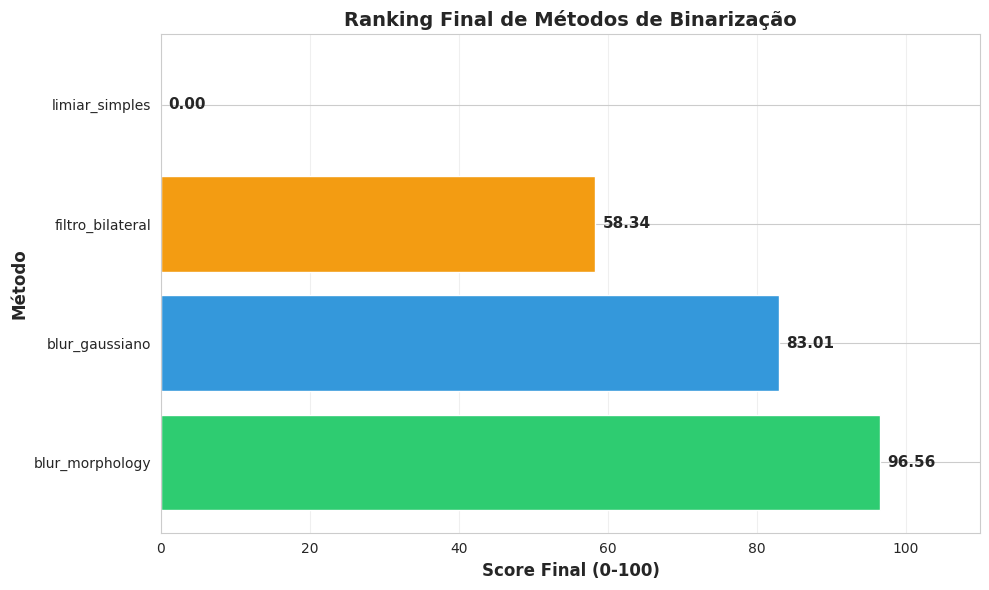

💾 Salvo: /home/victor/Projects/projeto-bufalos/generated/comparacao_ranking.png


In [14]:
# Gráfico de barras do ranking
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']

bars = ax.barh(df_scores['metodo'], df_scores['score_final'], color=colors)

# Adicionar valores nas barras
for i, (idx, row) in enumerate(df_scores.iterrows()):
    ax.text(row['score_final'] + 1, i, f"{row['score_final']:.2f}", 
            va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Score Final (0-100)', fontsize=12, fontweight='bold')
ax.set_ylabel('Método', fontsize=12, fontweight='bold')
ax.set_title('Ranking Final de Métodos de Binarização', fontsize=14, fontweight='bold')
ax.set_xlim(0, 110)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(Path(GENERATED_DIR) / 'comparacao_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💾 Salvo: {Path(GENERATED_DIR) / 'comparacao_ranking.png'}")

## 15. Recomendação Final

In [15]:
# Método vencedor
vencedor = df_scores.iloc[0]
segundo = df_scores.iloc[1]
diferenca = vencedor['score_final'] - segundo['score_final']

print("="*80)
print("🏆 RECOMENDAÇÃO FINAL - MÉTODO DE BINARIZAÇÃO PARA PRODUÇÃO")
print("="*80)
print(f"\n✅ MÉTODO SELECIONADO: {vencedor['metodo'].upper()}")
print(f"\n📊 Score Final: {vencedor['score_final']:.2f}/100")
print(f"📊 Vantagem sobre 2º lugar ({segundo['metodo']}): +{diferenca:.2f} pontos")

print("\n📋 JUSTIFICATIVA (Scores por Critério - CORRIGIDO):\n")
print(f"  • Consistência (40%):    {vencedor['score_consistencia']:.2f}/100")
print(f"  • Circularidade (30%):   {vencedor['score_circularidade']:.2f}/100")
print(f"  • Suavidade (30%):       {vencedor['score_suavidade']:.2f}/100")

print("\n📈 VALORES MÉDIOS DAS MÉTRICAS:\n")
print(f"  • CV Médio:              {vencedor['cv_medio']:.2f}% (menor = mais consistente)")
print(f"  • Circularidade Média:   {vencedor['circularidade']:.4f} (ideal = 1.0)")
print(f"  • Suavidade de Borda:    {vencedor['suavidade']:.4f} (menor = mais suave)")
print(f"  • Fragmentos Médios:     {vencedor['fragmentacao']:.2f} (referência - não pontuado)")
print(f"  • Buracos Médios:        {vencedor['buracos']:.2f} (referência - não pontuado)")

print("\n" + "="*80)
print("💡 PRÓXIMOS PASSOS:")
print("="*80)
print(f"\n1. Atualizar pipeline de produção para usar: {vencedor['metodo']}")
print("2. Validar resultados com conjunto de teste independente")
print("3. Documentar parâmetros do método selecionado")
print("4. Considerar re-processar dataset completo com método vencedor")
print("\n")

🏆 RECOMENDAÇÃO FINAL - MÉTODO DE BINARIZAÇÃO PARA PRODUÇÃO

✅ MÉTODO SELECIONADO: BLUR_MORPHOLOGY

📊 Score Final: 96.56/100
📊 Vantagem sobre 2º lugar (blur_gaussiano): +13.55 pontos

📋 JUSTIFICATIVA (Scores por Critério - CORRIGIDO):

  • Consistência (40%):    91.40/100
  • Circularidade (30%):   100.00/100
  • Suavidade (30%):       100.00/100

📈 VALORES MÉDIOS DAS MÉTRICAS:

  • CV Médio:              51.04% (menor = mais consistente)
  • Circularidade Média:   0.1995 (ideal = 1.0)
  • Suavidade de Borda:    0.5221 (menor = mais suave)
  • Fragmentos Médios:     1.03 (referência - não pontuado)
  • Buracos Médios:        0.55 (referência - não pontuado)

💡 PRÓXIMOS PASSOS:

1. Atualizar pipeline de produção para usar: blur_morphology
2. Validar resultados com conjunto de teste independente
3. Documentar parâmetros do método selecionado
4. Considerar re-processar dataset completo com método vencedor




## 16. Exportação de Resultados Completos

In [16]:
# Exportar DataFrame completo com todas as métricas
df.to_csv(Path(GENERATED_DIR) / 'comparacao_binarizacao_metricas.csv', index=False)

print("💾 Arquivos Exportados:\n")
print(f"  1. {Path(GENERATED_DIR) / 'comparacao_binarizacao_metricas.csv'}")
print(f"     └─ {len(df)} registros (4 métodos × 387 imagens)\n")

print(f"  2. {Path(GENERATED_DIR) / 'comparacao_binarizacao_ranking.csv'}")
print(f"     └─ Ranking final com scores normalizados\n")

print(f"  3. {Path(GENERATED_DIR) / 'comparacao_binarizacao_resumo.csv'}")
print(f"     └─ Estatísticas descritivas por método\n")

print("📊 Visualizações Salvas:\n")
print(f"  • comparacao_sidebyside.png")
print(f"  • comparacao_histogramas.png")
print(f"  • comparacao_boxplots.png")
print(f"  • comparacao_scatterplots.png")
print(f"  • comparacao_correlacoes.png")
print(f"  • comparacao_ranking.png")

print("\n✅ Análise completa!")

💾 Arquivos Exportados:

  1. /home/victor/Projects/projeto-bufalos/generated/comparacao_binarizacao_metricas.csv
     └─ 1548 registros (4 métodos × 387 imagens)

  2. /home/victor/Projects/projeto-bufalos/generated/comparacao_binarizacao_ranking.csv
     └─ Ranking final com scores normalizados

  3. /home/victor/Projects/projeto-bufalos/generated/comparacao_binarizacao_resumo.csv
     └─ Estatísticas descritivas por método

📊 Visualizações Salvas:

  • comparacao_sidebyside.png
  • comparacao_histogramas.png
  • comparacao_boxplots.png
  • comparacao_scatterplots.png
  • comparacao_correlacoes.png
  • comparacao_ranking.png

✅ Análise completa!


## 17. Análise Detalhada do Método Vencedor (Opcional)

Explore características específicas do método selecionado.

In [17]:
# Análise detalhada do vencedor
metodo_vencedor = vencedor['metodo']
dados_vencedor = df[df['metodo'] == metodo_vencedor]

print(f"🔍 Análise Detalhada: {metodo_vencedor.upper()}\n")
print("="*80)

# Outliers (valores extremos)
print("\n📊 OUTLIERS (Top 5 valores extremos):\n")

for metrica in ['area', 'perimetro', 'circularidade']:
    top5 = dados_vencedor.nlargest(5, metrica)
    print(f"\n{metrica.upper()} (maiores):")
    for idx, row in top5.iterrows():
        print(f"  • {row['imagem']}: {row[metrica]:.2f}")

# Imagens mais problemáticas (maior fragmentação ou buracos)
print("\n\n⚠️  IMAGENS MAIS PROBLEMÁTICAS:\n")

problematicas = dados_vencedor[
    (dados_vencedor['fragmentos'] > 1) | (dados_vencedor['buracos'] > 0)
].sort_values('fragmentos', ascending=False)

if len(problematicas) > 0:
    print(f"Total: {len(problematicas)} imagens com fragmentação ou buracos\n")
    print(problematicas[['imagem', 'fragmentos', 'buracos']].head(10))
else:
    print("✅ Nenhuma imagem com fragmentação ou buracos detectados!")

print("\n" + "="*80)

🔍 Análise Detalhada: BLUR_MORPHOLOGY


📊 OUTLIERS (Top 5 valores extremos):


AREA (maiores):
  • B8_Laje-Nova_131.png: 5136356.00
  • B2_Laje-Nova_184.png: 4461943.00
  • 49_Laje-Nova_343.png: 4095835.00
  • 45_Laje-Nova_342.png: 4034591.00
  • 55_Laje-Nova_412.png: 4030794.00

PERIMETRO (maiores):
  • B8_Laje-Nova_131.png: 19273.19
  • 55_Laje-Nova_412.png: 18290.15
  • 49_Laje-Nova_343.png: 17532.10
  • B11_Laje-Nova_190.png: 17425.62
  • 48_Laje-Nova_531.png: 17229.34

CIRCULARIDADE (maiores):
  • 6a9b6ed5-caad-4a0f-8426-cd389710654b.png: 0.45
  • 660564b0-133b-452c-8a0e-325452dc5275.png: 0.44
  • a0da37bc-465e-4a73-9280-ac19104e607a.png: 0.41
  • 22b41082-f8da-42c6-9595-abe9dd185e61.png: 0.40
  • 3aa1c73a-49c0-4989-97c9-70f8b098e8fe.png: 0.40


⚠️  IMAGENS MAIS PROBLEMÁTICAS:

Total: 167 imagens com fragmentação ou buracos

                                       imagem  fragmentos  buracos
50                        118_Calcula_490.png           3        0
41                       